In [2]:
import pandas as pd

df = pd.read_csv("../r_50_5.csv")
df.head()


,example_id,original_id,title,profession,purpose,original_text_length,iteration_number,structure_score,coverage_score,focus_relevance_score,...,focus_relevance_reasoning,redundancy_reasoning,combined_feedback,output,refinement_reasoning,is_final_iteration,converged_early,total_iterations,current_best_score,current_best_iteration
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,1,0.85,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Text Entry on Smartwatches: Challenges and R...,"To address the feedback, I added a one-line su...",False,False,2,0.8875,1
1,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,2,1.00,1.00,1.00,...,The restructured text remains focused and rele...,The output text contains several instances of ...,NaN,# Smartwatch Text Entry Challenges and Researc...,NaN,True,True,2,0.9775,2
2,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,1,0.85,0.85,0.85,...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I added a one-line su...",False,False,5,0.8125,1
3,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,2,0.85,0.85,0.95,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made several change...",False,False,5,0.8500,2
4,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,3,0.85,1.00,1.00,...,The restructured text remains focused on the o...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made the following ...",False,False,5,0.8875,3


In [3]:
first_iterations = df[df['iteration_number'] == 1].reset_index(drop=True)
first_iterations.head()

,example_id,original_id,title,profession,purpose,original_text_length,iteration_number,structure_score,coverage_score,focus_relevance_score,...,focus_relevance_reasoning,redundancy_reasoning,combined_feedback,output,refinement_reasoning,is_final_iteration,converged_early,total_iterations,current_best_score,current_best_iteration
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,1,0.85,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Text Entry on Smartwatches: Challenges and R...,"To address the feedback, I added a one-line su...",False,False,2,0.8875,1
1,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,1,0.85,0.85,0.85,...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I added a one-line su...",False,False,5,0.8125,1
2,example_003,1e2b27f9-1aad-4307-9eec-380df6abca2a,Tips for Student Justices & Student Clerk,teacher/lecturer,school,1679,1,0.85,0.90,1.00,...,The restructured text effectively captures the...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Guidelines for Student Justices\n\n## Prepar...,"To enhance clarity, I added a one-line summary...",False,False,2,0.8675,1
3,example_004,5a77524d-46c4-42a6-8b4a-3b6654df20c7,SUMMARY,psychologist,work,2318,1,0.85,0.85,1.00,...,The restructured text maintains a strong focus...,The output text contains some redundancy in th...,- Add a one-line summary immediately after the...,# The Role of Religion in Mental Health\n\nRel...,"To address the feedback, I added a one-line su...",False,False,5,0.8500,1
4,example_005,51a1f095-cda5-4691-9a41-07da40242b90,Turkcell,it specialist,work,1213,1,1.00,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...","- Remove redundancy in the ""Benefits"" section,...",# Turkcell Enhances Services with Affirmed Net...,To address the feedback regarding redundancy i...,False,False,5,0.9625,1


In [4]:
df.columns

Index(['example_id', 'original_id', 'title', 'profession', 'purpose',
       'original_text_length', 'iteration_number', 'structure_score',
       'coverage_score', 'focus_relevance_score', 'redundancy_score',
       'combined_score', 'structure_reasoning', 'coverage_reasoning',
       'focus_relevance_reasoning', 'redundancy_reasoning',
       'combined_feedback', 'output', 'refinement_reasoning',
       'is_final_iteration', 'converged_early', 'total_iterations',
       'current_best_score', 'current_best_iteration'],
      dtype='object')

In [5]:
columns_to_drop = [
    'refinement_reasoning',
    'is_final_iteration', 
    'converged_early',
    'total_iterations',
    'current_best_score',
    'current_best_iteration',
    'output',
    'iteration_number',
]

# Drop the refinement-related columns
first_iterations_clean = first_iterations.drop(columns=columns_to_drop)
first_iterations_clean.head()

,example_id,original_id,title,profession,purpose,original_text_length,structure_score,coverage_score,focus_relevance_score,redundancy_score,combined_score,structure_reasoning,coverage_reasoning,focus_relevance_reasoning,redundancy_reasoning,combined_feedback
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,0.85,1.00,1.00,0.75,0.8875,- The title is appropriate and follows the gui...,The output text successfully captures the main...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...
1,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,0.85,0.85,0.85,0.60,0.8125,- The title is appropriate and meets the lengt...,The output text captures the main ideas from t...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...
2,example_003,1e2b27f9-1aad-4307-9eec-380df6abca2a,Tips for Student Justices & Student Clerk,teacher/lecturer,school,1679,0.85,0.90,1.00,0.75,0.8675,- The title is appropriate and follows the gui...,The output text successfully captures the key ...,The restructured text effectively captures the...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...
3,example_004,5a77524d-46c4-42a6-8b4a-3b6654df20c7,SUMMARY,psychologist,work,2318,0.85,0.85,1.00,0.70,0.8500,- The title is appropriate and follows the gui...,The output text captures the majority of the k...,The restructured text maintains a strong focus...,The output text contains some redundancy in th...,- Add a one-line summary immediately after the...
4,example_005,51a1f095-cda5-4691-9a41-07da40242b90,Turkcell,it specialist,work,1213,1.00,1.00,1.00,0.75,0.9625,- The title is appropriate and follows the gui...,The output text successfully captures the key ...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...","- Remove redundancy in the ""Benefits"" section,..."


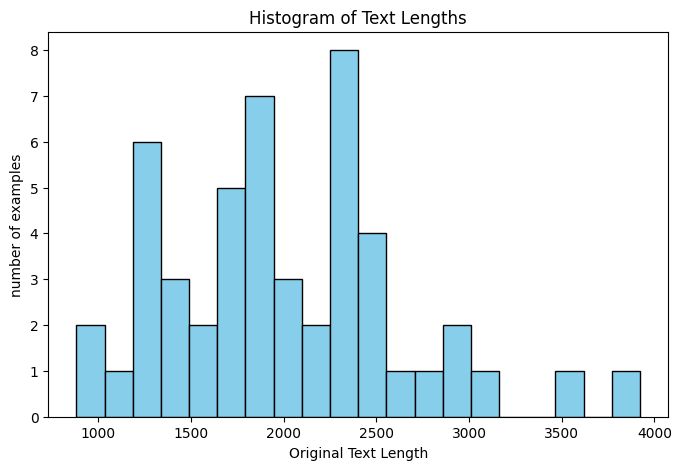

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(first_iterations_clean['original_text_length'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Original Text Length')
plt.ylabel('number of examples')
plt.title('Histogram of Text Lengths')
plt.show()


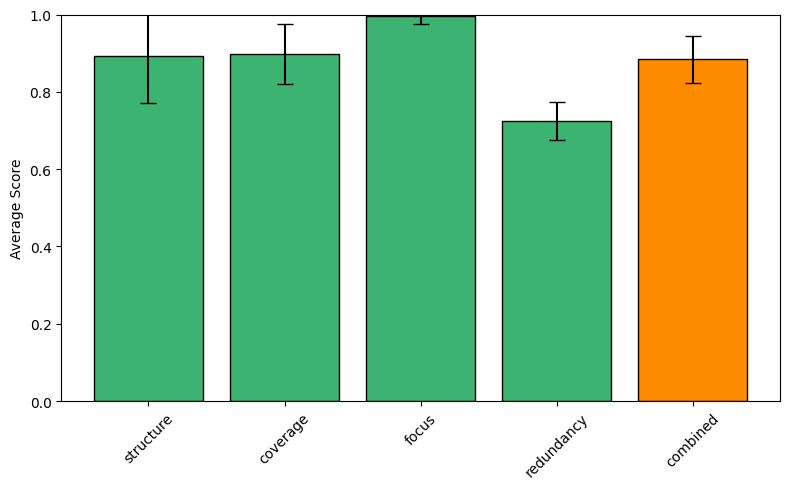

In [7]:
# Plot average scores and variances of all judges

import numpy as np

# Identify all columns that end with '_score'
score_columns = [col for col in first_iterations_clean.columns if col.endswith('_score')]

# Compute the mean and variance for each score column
avg_scores = first_iterations_clean[score_columns].mean()
score_variances = first_iterations_clean[score_columns].var()

# Remove the word 'score' (and optional underscore) from x tick labels
xtick_labels = ['structure', 'coverage', 'focus', 'redundancy', 'combined']

# Set bar colors: all green except 'combined' (last one) as orange
bar_colors = ['mediumseagreen'] * (len(xtick_labels) - 1) + ['darkorange']

# Plot with error bars for variance (standard deviation)
plt.figure(figsize=(8, 5))
plt.bar(
    xtick_labels,
    avg_scores.values,
    yerr=np.sqrt(score_variances.values),
    color=bar_colors,
    edgecolor='black',
    capsize=6,
)
plt.ylabel('Average Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
# Print top 5 best scoring texts and 5 worst scoring texts by 'combined_score'

# Sort by combined_score (descending for best, ascending for worst)
top5 = first_iterations_clean.sort_values('combined_score', ascending=False).head(5)
bottom5 = first_iterations_clean.sort_values('combined_score', ascending=True).head(5)

print("Top 5 Best Scoring Texts:")
for idx, row in top5.iterrows():
    print(f"\nExample ID: {row['example_id']}")
    print(f"Original ID: {row['original_id']}")
    print(f"Combined Score: {row['combined_score']}")
    print("-" * 60)

print("\n" + "="*80 + "\n")

print("Bottom 5 Worst Scoring Texts:")
for idx, row in bottom5.iterrows():
    print(f"\nExample ID: {row['example_id']}")
    print(f"Original ID: {row['original_id']}")
    print(f"Combined Score: {row['combined_score']}")
    print("-" * 60)


Top 5 Best Scoring Texts:

Example ID: example_029
Original ID: 27eb9354-3bd4-4fc8-8646-5de5e79d8c22
Combined Score: 0.9625
------------------------------------------------------------

Example ID: example_023
Original ID: a541cfc6-ad50-4f62-bef6-2a4362e6532f
Combined Score: 0.9625
------------------------------------------------------------

Example ID: example_046
Original ID: ee20bef7-45e1-493f-b0ef-b5262b3abc96
Combined Score: 0.9625
------------------------------------------------------------

Example ID: example_005
Original ID: 51a1f095-cda5-4691-9a41-07da40242b90
Combined Score: 0.9625
------------------------------------------------------------

Example ID: example_043
Original ID: 351efbe2-cede-4eb5-be09-00ea165fa9ff
Combined Score: 0.955
------------------------------------------------------------


Bottom 5 Worst Scoring Texts:

Example ID: example_015
Original ID: 2bbfadc4-a0dc-466f-9b20-1fddbe564437
Combined Score: 0.7575
--------------------------------------------------

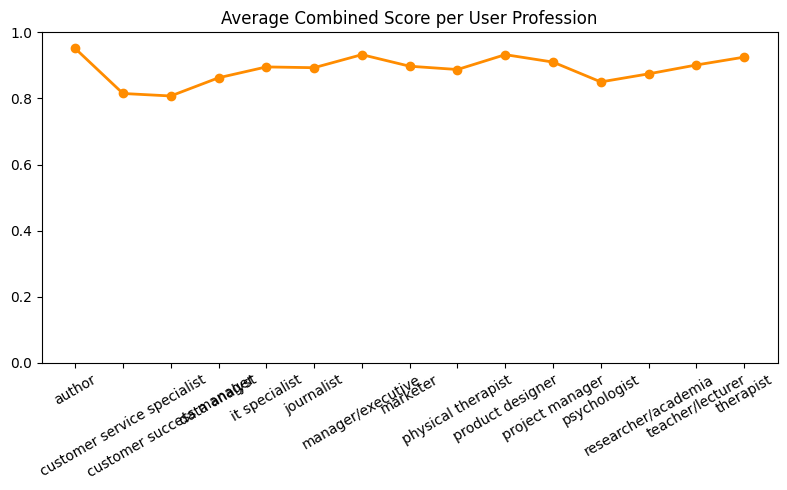

In [12]:
# Plot the average combined score per user profession as a line graph

import matplotlib.pyplot as plt

# Group by profession and calculate mean combined score
prof_group = first_iterations_clean.groupby('profession')['combined_score'].mean()

plt.figure(figsize=(8, 5))
x = np.arange(len(prof_group.index))

plt.plot(x, prof_group.values, marker='o', color='darkorange', linewidth=2)
plt.xticks(x, prof_group.index, rotation=30)
plt.ylim(0, 1)
plt.title('Average Combined Score per User Profession')
plt.tight_layout()
plt.show()
